# CAM History Panel Plot
Reads a single CAM monthly history file and plots a 2-column × 3-row panel,
one subplot per variable / pressure level, each with its own colorbar.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from pathlib import Path

---
## TOP LEVEL OPTIONS

In [12]:
# ── File location ──────────────────────────────────────────────────────────

CASENAME = 'f.e22.FHIST.f09_f09.cesm2_2.budget.002'
BASE_DIR = '/glade/derecho/scratch/rneale/archive/'+CASENAME+'/atm/hist/'
CAM_HIST = 'h0'    # history stream: h0, h1, h2 …
YEAR     = 1980      # integer; zero-padded to 4 digits in the filename
MONTH    = 1       # integer 1–12

# ── Output figure directory ────────────────────────────────────────────────
FIG_DIR  = '/glade/u/home/rneale/python/python-figs/cam_history'
FIG_OUT  = True    # save PNG?

# ── Panel definitions ─────────────────────────────────────────────────────
# Each entry: (varname, pressure_hPa, colormap)
#   pressure_hPa : target level in hPa; nearest level selected automatically.
#                  Set to None for variables with no vertical dimension.
#   colormap     : any matplotlib colormap name.
#                  Diverging maps (e.g. 'RdBu_r') are auto-centred on zero.
PANELS = [
    ('UPWP_CLUBB', 850,  'RdBu_r'),
    ('VPWP_CLUBB', 850,  'RdBu_r'),
    ('FU',         250,  'RdBu_r'),
    ('FV',         250,  'RdBu_r'),
    ('UTEND_CLUBB',      850,  'RdBu_r'),
    ('VTEND_CLUBB',     850, 'RdBu_r'),
]

# ── Contour levels ────────────────────────────────────────────────────────
N_LEVELS   = 21    # number of contour fill levels
PCTILE_SAT = 98    # percentile used to set colorbar limits (avoids outliers)

fpath = Path(BASE_DIR) / f'{CASENAME}.cam.{CAM_HIST}.{YEAR:04d}-{MONTH:02d}.nc'
print(f'File: {fpath}')

File: /glade/derecho/scratch/rneale/archive/f.e22.FHIST.f09_f09.cesm2_2.budget.002/atm/hist/f.e22.FHIST.f09_f09.cesm2_2.budget.002.cam.h0.1980-01.nc


---
## 1. Load file

In [13]:
ds = xr.open_dataset(fpath)

print(f'Dimensions : {dict(ds.dims)}')
print(f'lev  range : {float(ds.lev.min()):.1f} – {float(ds.lev.max()):.1f} hPa'
      if 'lev'  in ds else '')
print(f'ilev range : {float(ds.ilev.min()):.1f} – {float(ds.ilev.max()):.1f} hPa'
      if 'ilev' in ds else '')
print()

for varname, plev, _ in PANELS:
    if varname in ds:
        da   = ds[varname]
        ldim = 'lev' if 'lev' in da.dims else 'ilev' if 'ilev' in da.dims else None
        if ldim and plev is not None:
            actual = float(ds[ldim].sel({ldim: plev}, method='nearest'))
            print(f'  {varname:20s}  requested {plev} hPa  → nearest {actual:.1f} hPa ({ldim})')
        elif ldim is None:
            print(f'  {varname:20s}  2-D field (no level dimension)')
        else:
            print(f'  {varname:20s}  on {ldim} (no plev requested)')
    else:
        print(f'  {varname:20s}  *** NOT FOUND IN FILE ***')

Dimensions : {'lat': 192, 'lev': 32, 'ilev': 33, 'time': 1, 'nbnd': 2, 'lon': 288}
lev  range : 3.6 – 992.6 hPa
ilev range : 2.3 – 1000.0 hPa

  UPWP_CLUBB            requested 850 hPa  → nearest 845.4 hPa (ilev)
  VPWP_CLUBB            requested 850 hPa  → nearest 845.4 hPa (ilev)
  FU                    requested 250 hPa  → nearest 232.8 hPa (lev)
  FV                    requested 250 hPa  → nearest 232.8 hPa (lev)
  UTEND_CLUBB           requested 850 hPa  → nearest 859.5 hPa (lev)
  VTEND_CLUBB           requested 850 hPa  → nearest 859.5 hPa (lev)


/glade/derecho/scratch/rneale/tmp/ipykernel_60497/546734042.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'Dimensions : {dict(ds.dims)}')


---
## 2. Panel plot

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the Maske

Saved: /glade/u/home/rneale/python/python-figs/cam_history/cam_panels_h0_1980-01.png


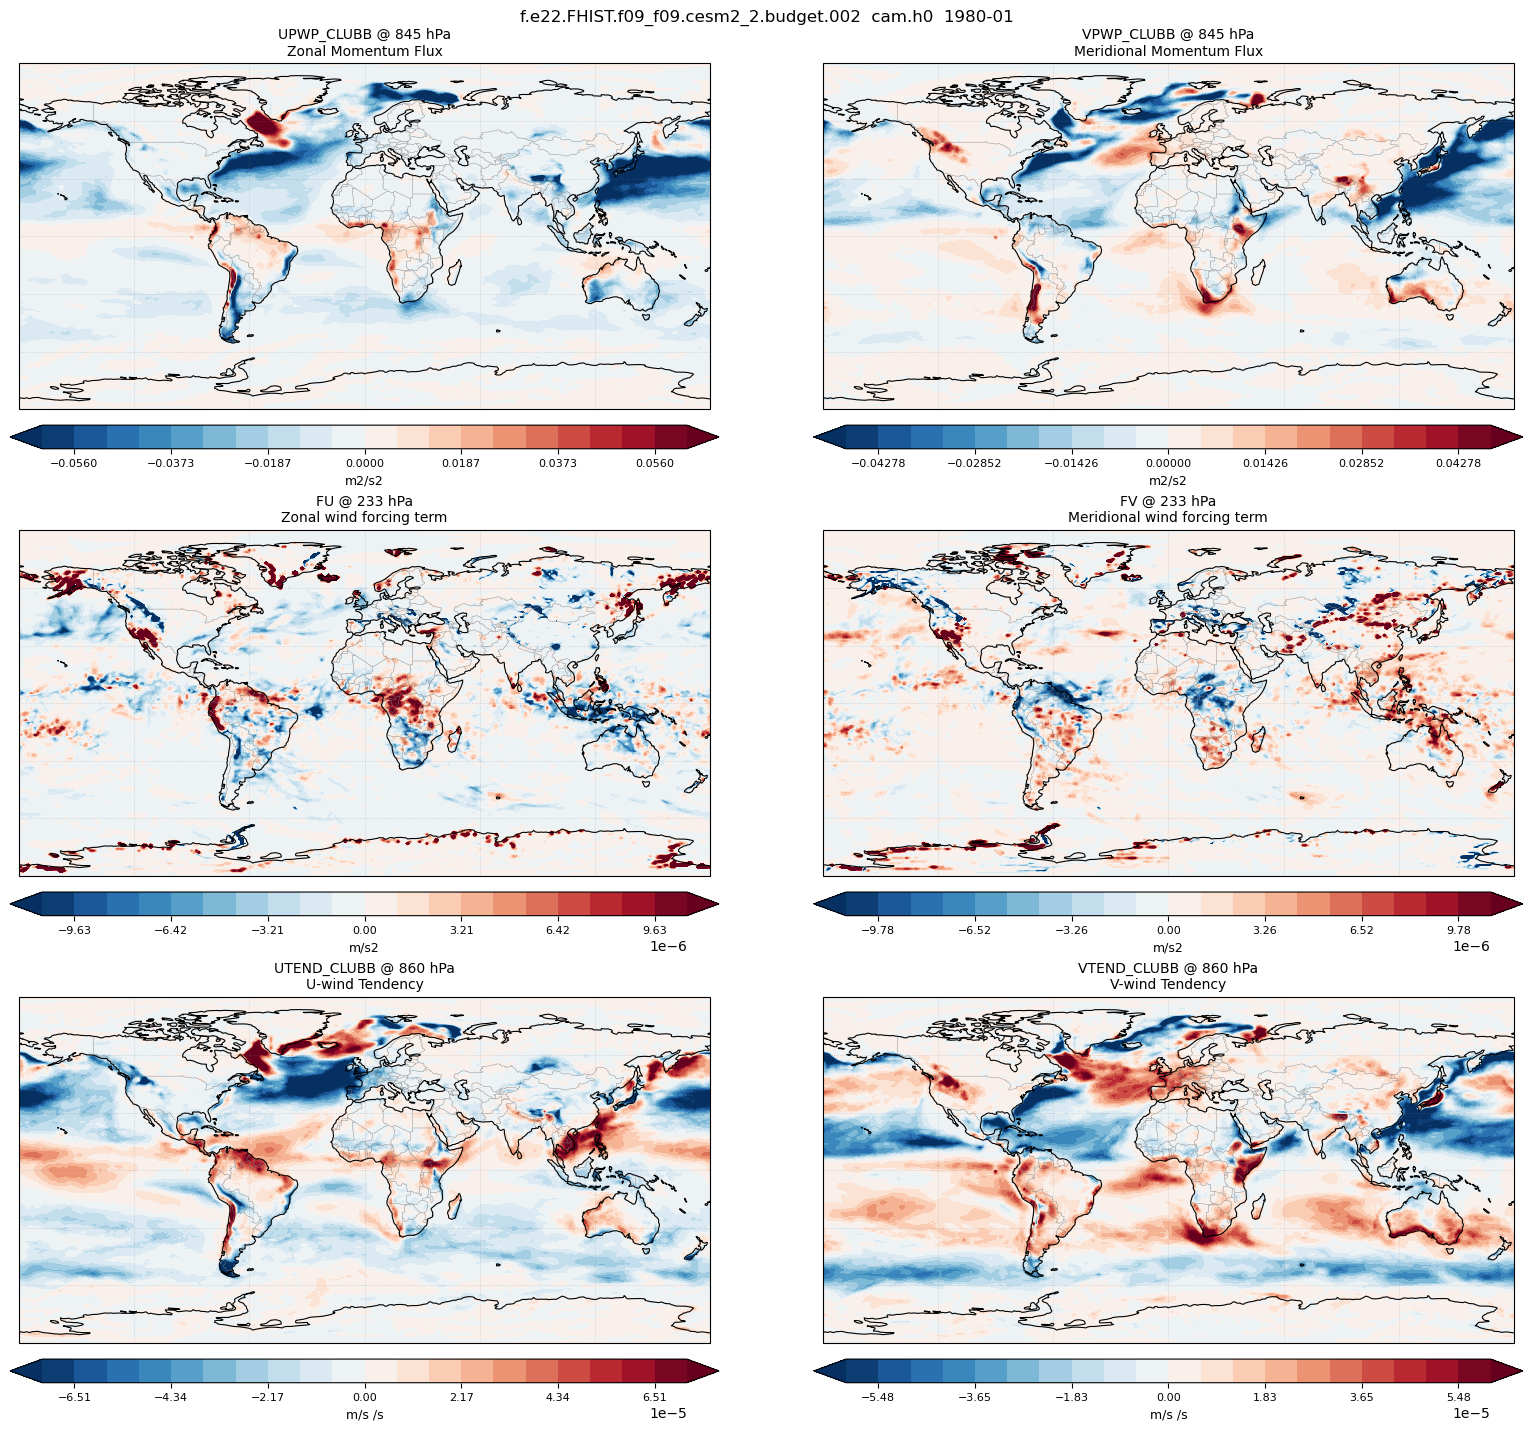

In [14]:
_DIVERGING = {
    'RdBu_r','RdBu','bwr','seismic','coolwarm','PiYG','PRGn','BrBG','PuOr',
    'RdGy','RdYlBu','RdYlGn','Spectral',
}


def _extract_level(ds, varname, plev_hPa):
    """
    Return (DataArray[lat,lon], actual_level_hPa or None) for a variable.
    Handles lev, ilev, and purely 2-D fields.  Returns (None, None) if the
    variable is absent from the dataset.
    """
    if varname not in ds:
        return None, None
    da = ds[varname].isel(time=0)
    if 'lev' in da.dims:
        if plev_hPa is not None:
            da = da.sel(lev=plev_hPa, method='nearest')
            return da, float(da.lev)
        else:
            da = da.isel(lev=0)          # fallback: first level
            return da, float(da.lev)
    elif 'ilev' in da.dims:
        if plev_hPa is not None:
            da = da.sel(ilev=plev_hPa, method='nearest')
            return da, float(da.ilev)
        else:
            da = da.isel(ilev=0)
            return da, float(da.ilev)
    else:
        return da, None   # 2-D surface field


# ── Figure setup ──────────────────────────────────────────────────────────
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 14),
    subplot_kw={'projection': proj},
    constrained_layout=True,
)

for ax, (varname, plev, cmap) in zip(axes.flat, PANELS):

    da, actual_lev = _extract_level(ds, varname, plev)

    # ── Missing variable ──────────────────────────────────────────────────
    if da is None:
        ax.set_global()
        ax.coastlines(linewidth=0.7)
        ax.set_title(f'{varname}  [NOT FOUND]', fontsize=11, color='red')
        continue

    # ── Cyclic point (closes longitude wrap) ──────────────────────────────
    data_cyc, lon_cyc = add_cyclic_point(da.values, coord=da.lon.values)
    lat_vals = da.lat.values

    # ── Colour limits ─────────────────────────────────────────────────────
    finite = data_cyc[np.isfinite(data_cyc)]
    if cmap in _DIVERGING:
        vmax = np.percentile(np.abs(finite), PCTILE_SAT)
        vmin = -vmax
    else:
        vmin = np.percentile(finite, 100 - PCTILE_SAT)
        vmax = np.percentile(finite,       PCTILE_SAT)
    levels = np.linspace(vmin, vmax, N_LEVELS)

    # ── Filled contours ───────────────────────────────────────────────────
    cf = ax.contourf(
        lon_cyc, lat_vals, data_cyc,
        levels=levels,
        cmap=cmap,
        extend='both',
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines(linewidth=0.8, color='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax.set_global()
    gl = ax.gridlines(draw_labels=False, color='gray', alpha=0.4,
                      linewidth=0.5, linestyle=':')

    # ── Title ─────────────────────────────────────────────────────────────
    lev_str  = f' @ {actual_lev:.0f} hPa' if actual_lev is not None else ''
    units    = ds[varname].attrs.get('units', '')
    longname = ds[varname].attrs.get('long_name', varname)
    ax.set_title(f'{varname}{lev_str}\n{longname}', fontsize=10)

    # ── Per-panel colorbar ────────────────────────────────────────────────
    cbar = fig.colorbar(cf, ax=ax, orientation='horizontal',
                        pad=0.04, shrink=0.9, aspect=30)
    cbar.set_label(units, fontsize=9)
    cbar.ax.tick_params(labelsize=8)

yr_str   = f'{YEAR:04d}'
mon_str  = f'{MONTH:02d}'
fig.suptitle(
    f'{CASENAME}  cam.{CAM_HIST}  {yr_str}-{mon_str}',
    fontsize=12, y=1.01,
)

if FIG_OUT:
    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
    fout = Path(FIG_DIR) / f'cam_panels_{CAM_HIST}_{yr_str}-{mon_str}.png'
    plt.savefig(fout, dpi=120, bbox_inches='tight')
    print(f'Saved: {fout}')

plt.show()